In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyRegressor
from sklearn.metrics import r2_score

import itertools

sns.set_theme()

In [2]:
data=pd.read_csv('Assignment3.csv')
X, y=data.drop('y', axis=1), data['y'].copy()

In [16]:
def sse(y_true, y_pred):
    return np.sum((y_true-y_pred)**2)

def rmse(y_true, y_pred):
    return (sse(y_true, y_pred)/y_true.shape[0])**0.5

def adjusted_r2(y_true, y_pred, n_input_vars):
    return 1-(1-r2_score(y_true, y_pred))*(y_true.shape[0]-1)/(y_true.shape[0]-n_input_vars-1)

# Task 1

In [14]:
reg=LinearRegression()
reg.fit(X, y)

LinearRegression()

In [17]:
predictions=reg.predict(X)
print('SSE: %1.2f'%sse(y, predictions))
print('RMSE: %1.2f'%rmse(y, predictions))
print('Adjusted R2: %1.2f'%adjusted_r2(y, predictions, reg.n_features_in_))

SSE: 71877.84
RMSE: 26.68
Adjusted R2: 1.00


OLS model was fit on the whole dataset with $bias$ or $intercept$. The $SSE$ comes out to be $71877.84$ which is a very high value. But the $Adjusted R2$ value is 1, which sugeests the regression actually performed well. We look at deeper insights in the next section.

# Task 2

Let us first look at the table of descriptive statistics of all the features (input as well as output).

In [6]:
data.describe()

,x1,x2,x3,x4,x5,y
count,101.00,101.00,101.00,101.00,101.00,101.00
mean,7.55,23.76,111.37,98.13,34.00,10244.46
std,0.38,292.85,55.81,4.94,30.56,1022.77
min,6.68,-466.86,9.80,86.83,0.00,8062.54
25%,7.25,-208.89,66.38,94.24,6.76,9469.94
50%,7.53,38.95,104.18,97.90,25.00,10187.66
75%,7.80,262.92,168.16,101.42,57.76,10866.63
max,8.37,546.88,195.81,108.85,100.00,12631.05


We observe that:
1) No feature has null values.
2) Out of the input features, $x_2$ has the maximum standard deviation, while $x_1$ having the lowest standard deviation.
3) $y$ has a hight standard deviation and the scale of $y$ is also in the order of $10^4$. This explains the high $SSE$ of the regression performed on the dataset. 

Let us look at the pairwise scatter plots and correlations of all the features.

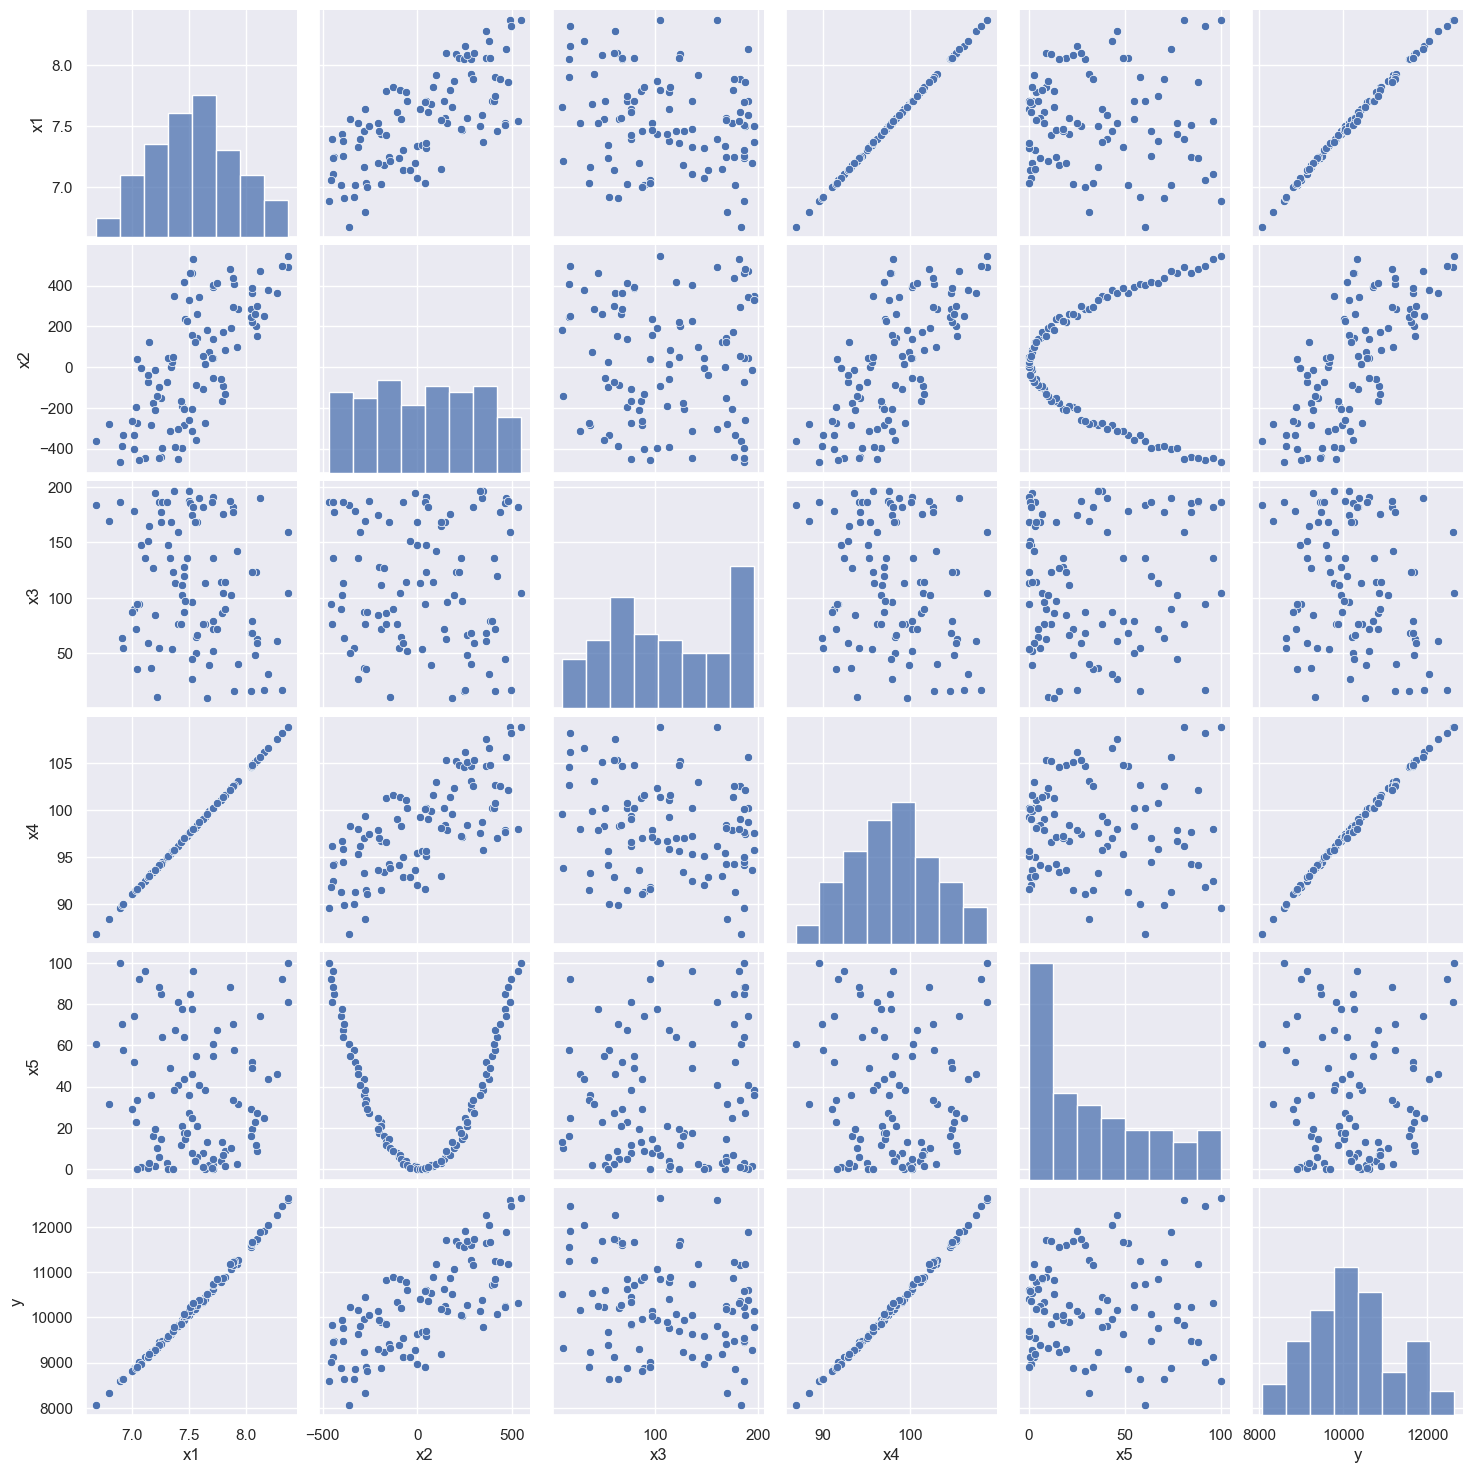

In [7]:
sns.pairplot(data);

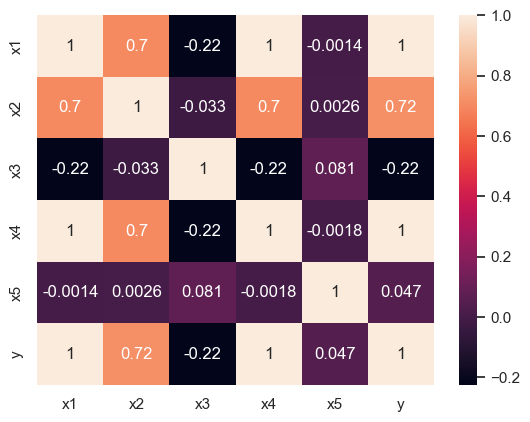

In [8]:
sns.heatmap(data.corr(), annot=True);

### Observations and Interpretations
##### Relation between input features and output feature
These observations can be made by looking at the row corresponding to to the label $y$ of the above two plots.
1) $x_1$ and $y$ are highly correlated having a correlation of 1. The corresponding scatter plot also suggests that $y$ has a strong linear relation with $x_1$
2) Similarly $x_4$ and $y$ are highly correlated having a correlation of 1. The corresponding scatter plot also suggests that $y$ has a strong linear relation with $x_4$
3) $x_2$ and $y$ are also highly correlated having a correlation of 0.72. The corresponding scatter plot also suggests that $y$ has a linear relation with $x_2$, but this relation is not as strong as what $y$ has with $x_1$ and $x_4$.
4) $x_3$ has a weak negative correlation with $y$. The scatter plot does not reveal any interesting linear relation between $x_3$ and $y$.
5) $x_5$ does not have seem to be correlated to $y$. The scatter plot is spread out.

<br/>

##### Relation among input features
1) $x_1$ and $x_4$ show a correlation of 1. The scatter plot also illustrates a strong linear relationship. $x_4$ can be thought of a scaled version $x_1$.
2) $x_1$ and $x_2$ also show a strong positive correlation of 0.7. The scatter plot also shows that when, $x_1$ increases, then $x_2$ also increases.
3) The scatter plot between $x_2$ and $x_5$ show almost a perfect parabolic relationship.

<br/>

##### Inferences
1) Either $x_4$ or $x_1$ can be dropped as they have a perfect correlation of 1.
2) $x_3$ and $x_5$ do not seem to show any linear relationship with $y$ but they are not dropped for now.

<br/>

Moving on, the dataset will be split into Training and Testing data. The data will be trained on diifferent combinations of the features. This can be done as only 5 features are there. This will also resolve the choice of dropping $x_1$ or $x_4$.

# Task3

In [31]:
X_train, X_test, y_train, y_test=train_test_split(X, y, random_state=0)

In [32]:
for r in range(1, 6):
    for i in itertools.combinations(X.columns, r=r):
        print('Features used', end=': ')
        print(i)
        reg_temp=LinearRegression()
        X_temp=X_train[[*i]]
        reg_temp.fit(X_temp, y_train)
        predictions=reg_temp.predict(X_temp)
        print('  Training Performance:')
        print('\tSSE: %1.2f'%sse(y_train, predictions))
        print('\tRMSE: %1.2f'%rmse(y_train, predictions))

        X_temp=X_test[[*i]]
        predictions=reg_temp.predict(X_temp)
        print('  Testing Performance:')
        print('\tSSE: %1.2f'%sse(y_test, predictions))
        print('\tRMSE: %1.2f'%rmse(y_test, predictions))
        print('\tAdjusted R2: %1.2f'%adjusted_r2(y_test, predictions, reg_temp.n_features_in_))
        print('=========================')

Features used: ('x1',)
  Training Performance:
	SSE: 295073.35
	RMSE: 62.72
  Testing Performance:
	SSE: 78517.57
	RMSE: 54.95
	Adjusted R2: 1.00
Features used: ('x2',)
  Training Performance:
	SSE: 42328910.03
	RMSE: 751.26
  Testing Performance:
	SSE: 8642981.42
	RMSE: 576.56
	Adjusted R2: 0.66
Features used: ('x3',)
  Training Performance:
	SSE: 75357243.01
	RMSE: 1002.38
  Testing Performance:
	SSE: 24353412.24
	RMSE: 967.82
	Adjusted R2: 0.04
Features used: ('x4',)
  Training Performance:
	SSE: 284969.32
	RMSE: 61.64
  Testing Performance:
	SSE: 77586.74
	RMSE: 54.63
	Adjusted R2: 1.00
Features used: ('x5',)
  Training Performance:
	SSE: 77671559.65
	RMSE: 1017.65
  Testing Performance:
	SSE: 26814570.80
	RMSE: 1015.54
	Adjusted R2: -0.06
Features used: ('x1', 'x2')
  Training Performance:
	SSE: 245959.57
	RMSE: 57.27
  Testing Performance:
	SSE: 78275.19
	RMSE: 54.87
	Adjusted R2: 1.00
Features used: ('x1', 'x3')
  Training Performance:
	SSE: 293034.49
	RMSE: 62.51
  Testing Perf

#### Inferences
1) In the models where either $x_1$ or $x_4$ or both were used, the $Adjusted R2$ score is 1. Which is in line with our speculation that $y$ is perfectly correlated with both these features.
2) All the models that invlove $x_4$ inplace of $x_1$ are marginally better than models that have $x_1$ in place of $x_4$. So $x_1$ will be dropped. Moreover, adding $x_1$ to all models that already have $x_4$ as input does not improve the performance significantly.
3) Individually, $x_5$ performs very badly, but when added with $x_4$ it significantly improves the performance of the model. For example, when $x_4$ is the sole feature, $RMSE_{test}=54.63$, but when $x_5$ is added to the model the $RMSE_{test}$ reduces to $33.69$.
4) Next, $x_2$ seems important as introduction of $x_2$ in the model with $x_4$ and $x_5$ significantly reduces the $RMSE_{test}$ value, from $33.69$ to $25.40$.
5) Introduction of $x_3$ does not significantly improve the models, in fact in many cases it is making the model worse.

<br/>
The above tests were done only because the number of features were less, and to confirm our speculation from EDA.


From the above analysis, we were not able to reduce the $SSE$ of training even after feature selection, but as discussed earlier $y$ is perfectly correlated with $x_4$ and the best features were found out to be $x_2$, $x_4$, $x_5$. The high $SSE$ can be attributed to the high scale of $y$.
Let us train our own Lasso Model to confirm the same.

In [54]:
lasso=Lasso(alpha=10)
lasso.fit(X_train, y_train)
predictions=lasso.predict(X_train)
print('Training Performance:')
print('\tSSE: %1.2f'%sse(y_train, predictions))
print('\tRMSE: %1.2f'%rmse(y_train, predictions))

predictions=lasso.predict(X_test)
print('Testing Performance:')
print('\tSSE: %1.2f'%sse(y_test, predictions))
print('\tRMSE: %1.2f'%rmse(y_test, predictions))
print('\tAdjusted R2: %1.2f'%adjusted_r2(y_test, predictions, lasso.n_features_in_))

predictions=lasso.predict(X)
print('AllData Performance:')
print('\tSSE: %1.2f'%sse(y, predictions))
print('\tRMSE: %1.2f'%rmse(y, predictions))
print('\tAdjusted R2: %1.2f'%adjusted_r2(y, predictions, lasso.n_features_in_))

Training Performance:
	SSE: 56974.59
	RMSE: 27.56
Testing Performance:
	SSE: 15693.03
	RMSE: 24.57
	Adjusted R2: 1.00
AllData Performance:
	SSE: 72667.62
	RMSE: 26.82
	Adjusted R2: 1.00


In [46]:
lasso.coef_

array([ 0.00000000e+00,  1.06822894e-01, -8.70615415e-02,  2.01958698e+02,
        1.62355933e+00])

We can clearly see that the Lasso Model drops $x_1$. Furthermore, the minimum weightage is giving to $x_3$ even though $x_3$ does not have the highest scale among features.

# Task 4

In [19]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=10)
lazy=LazyRegressor(ignore_warnings=True, verbose=0)
models, predictions=lazy.fit(X_train, X_test, y_train, y_test)

100%|██████████| 42/42 [00:02<00:00, 16.63it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000572 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 137
[LightGBM] [Info] Number of data points in the train set: 80, number of used features: 5
[LightGBM] [Info] Start training from score 10272.997791
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [48]:
models

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
Lasso,1.00,1.00,21.08,0.01
LassoCV,1.00,1.00,21.08,0.08
HuberRegressor,1.00,1.00,21.09,0.04
RidgeCV,1.00,1.00,21.81,0.03
SGDRegressor,1.00,1.00,21.85,0.02
BayesianRidge,1.00,1.00,22.35,0.03
PassiveAggressiveRegressor,1.00,1.00,22.51,0.03
LassoLars,1.00,1.00,22.59,0.01
Ridge,1.00,1.00,23.68,0.01


### Comparing The Best Model in Lazy Regressor with our Lasso Model in Task3

In [55]:
predictions=lazy.models['Lasso'].predict(X_train)
print('Training Performance:')
print('\tSSE: %1.2f'%sse(y_train, predictions))
print('\tRMSE: %1.2f'%rmse(y_train, predictions))



predictions=lazy.models['Lasso'].predict(X_test)
print('Testing Performance:')
print('\tSSE: %1.2f'%sse(y_test, predictions))
print('\tRMSE: %1.2f'%rmse(y_test, predictions))
print('\tAdjusted R2: %1.2f'%adjusted_r2(y_test, predictions, lasso.n_features_in_))

predictions=lazy.models['Lasso'].predict(X)
print('AllData Performance:')
print('\tSSE: %1.2f'%sse(y, predictions))
print('\tRMSE: %1.2f'%rmse(y, predictions))
print('\tAdjusted R2: %1.2f'%adjusted_r2(y, predictions, lasso.n_features_in_))

Training Performance:
	SSE: 62287.39
	RMSE: 28.82
Testing Performance:
	SSE: 17990.53
	RMSE: 26.30
	Adjusted R2: 1.00
AllData Performance:
	SSE: 80277.92
	RMSE: 28.19
	Adjusted R2: 1.00


Our Lasso Model from Task3 performs better than Lazy Predictor.

Lasso Model from Task3: $SSE=72667.62$

Lazy Predictor Lasso: $SSE=80277.92$

#### Inferences
1) The top 5 best performing models are all Linear Models. This is because, there exists a near perfect linear relationship between input feature $x_4$ and $y$. Naturally Linear Models perform the best.
2) KNeighborsRegressor does not perform well because the scale of different features is different and in that case the distance metric is influenced by the features that have the maximum scale.
3) All tree methods only approximate the output variable based on splits of data. Since there exists a near perfect linear relationship between the input and output feature, that approximation is not enough to beat the Linear Models. Tree models also typicaaly require huge data to produce good results, so, lack of data may also be a factor.